<a href="https://colab.research.google.com/github/viviantram03/labb-1/blob/main/lab4aml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
# check if a GPU is available and set the device accordingly
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

image_size = 32 # set size (width and height) of the images to 32 x 32
batch_size = 64 # number of images per training batch
nz = 100 # size of the latent z vector (size of generator input)
num_epochs = 50 # total number of traning epochs

transform = transforms.Compose([ # series of image transformations
    transforms.Resize(image_size), # resize the image to the specified size
    transforms.ToTensor(), # convert image to a PyTorch tensor
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # normalize the tensor values to the range [-1, 1]
])

print("Downloading CIFAR-10...")
dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform) # download and load the CIFAR-10 dataset
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2) # create a dataloader to fetch batches of data

num_classes = len(dataset.classes) # calculate the total number of classes in the dataset
print(f"Dataset successfully loaded. Classes: {dataset.classes} ({num_classes} total)")

Using device: cuda:0


100%|██████████| 170M/170M [00:17<00:00, 9.85MB/s]


Dataset successfully loaded. Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'] (10 total)


# VAE Implementation (task 1)

In [ ]:
class VAE(nn.Module): # define the Variational Autoencoder (VAE) class inhereting from nn.Module
  def __init__(self): # initialize VAE class
    super(VAE, self).__init__() # call the initialization of the parent class
    self.encoder = nn.Sequential( # define the encoder neural network
        nn.Conv2d(3, 32, 4, 2, 1), # 2D convolutional layer (input channels: 3, output: 32)
        nn.BatchNorm2d(32), # batch normalization for 32 channels
        nn.ReLU(True), # ReLU activation function
        nn.Conv2d(32, 64, 4, 2, 1), # 2D convolutional layer (input: 32, output: 64)
        nn.BatchNorm2d(64), # batch normalization for 64 channels
        nn.ReLU(True), # ReLU activation function
        nn.Flatten() # flatten the 2D output into a 1D tensor
    )

    self.fc_mu = nn.Linear(64 * 8 * 8, nz) # fully connected layer for the mean of the latent space
    self.fc_logvar = nn.Linear(64 * 8 * 8, nz) # fully connected layer for the log variance of the latent space

    self.decoder_input = nn.Linear(nz, 64 * 8 * 8) # fully connected layer to map latent space back to spatial dimensions
    self.decoder = nn.Sequential( # define the decoder neural network
        nn.ConvTranspose2d(64, 32, 4, 2, 1), # transposed convolution layer (upsampling)
        nn.BatchNorm2d(32), # batch normalization for 32 channels
        nn.ReLU(True), # ReLU activation function
        nn.ConvTranspose2d(32, 3, 4, 2, 1), # transposed convolution layer to output an RGB image
        nn.Tanh() # Tanh activation to scale outputs between -1 and 1
    )

  def encode(self, x): # define the encoding step
    h = self.encoder(x) # pass input x through the encoder
    return self.fc_mu(h), self.fc_logvar(h) # return the calculated mean and log variance

  def reparameterize(self, mu, logvar): # define the reparameterization trick
    std = torch.exp(0.5 * logvar) # calculate the standard deviation from the log variance
    eps = torch.randn_like(std) # sample random noise (epsilon) from a normal distribution
    return mu + eps * std # return the sampled latent vector z

  def decode(self, z): # define the decoding step
    h = self.decoder_input(z).view(-1, 64, 8, 8) # map latent vector z and reshape it for spatial upsampling
    return self.decoder(h) # pass the reshaped tensor through the decoder

  def forward(self, x): # define the forward pass of the model
    mu, logvar = self.encode(x) # get the mean and log variance from the encoder
    z = self.reparameterize(mu, logvar) # sample latent vector z
    return self.decode(z), mu, logvar # return reconstructed image, mean, and log variance

cVAE Implementation (task 2)

In [ ]:
class cVAE(nn.Module): # define the Conditional Variational Encoder (cVAE) class
  def __init__(self, n_classes): # initialize the cVAE class with the number of classes
    super(cVAE, self).__init__() # call the initialization of the parent class
    self.label_emb = nn.Embedding(n_classes, 50) # create an embedding layer for class labels
    self.label_transform_enc = nn.Linear(50, 32 * 32) # linear layer to transform embeddings for the encoder

    self.encoder = nn.Sequential( # define the encoder neural network
        nn.Conv2d(4, 32, 4, 2, 1), # 2D convolutional layer (4 input channels: 3 image + 1 label channel)
        nn.BatchNorm2d(32), # batch normalization
        nn.ReLU(True), # ReLU activation function
        nn.Conv2d(32, 64, 4, 2, 1), # 2D convolutional layer
        nn.BatchNorm2d(64), # batch normalization
        nn.ReLU(True), # ReLU activation function
        nn.Flatten() # flatten the output
    )

    self.fc_mu = nn.Linear(64 * 8 * 8, nz) # linear layer for latent space mean
    self.fc_logvar = nn.Linear(64 * 8 * 8, nz) # linear layer for latens space log variance

    self.label_transform_dec = nn.Linear(50, nz) # linear layer to transform label embeddings for the decoder
    self.decoder_input = nn.Linear(nz * 2, 64 * 8 * 8) # linear layer mapping combined latent vector and label to spatial dimensions
    self.decoder = nn.Sequential( # define the decoder neural network
        nn.ConvTranspose2d(64, 32, 4, 2, 1), # transposed 2D convolution
        nn.BatchNorm2d(32), # batch normalization
        nn.ReLU(True), # ReLU activation function
        nn.ConvTranspose2d(32, 3, 4, 2, 1), # transposed 2D convolution for the final image
        nn.Tanh() # Tanh activation function
    )

  def encode(self, x, labels): # define encoding step taking images and labels
    y_emb = self.label_emb(labels) # get the embedding fot the given labels
    y_cond = self.label_transform_enc(y_emb).view(-1, 1, 32, 32) # transform and reshape the label embedding to match image dimensions
    inputs = torch.cat([x, y_cond], dim=1) # concatenate the image and label conditioning tensors
    h = self.encoder(inputs) # pass concatenated inputs to the encoder
    return self.fc_mu(h), self.fc_logvar(h) # return mean and log variance

  def reparameterize(self, mu, logvar): # reparameterization trick for sampling
    std = torch.exp(0.5 * logvar) # calculate standard deviation
    eps = torch.randn_like(std) # generate random noise
    return mu + eps * std # return sampled latent representation

  def decode(self, z, labels): # define decoding step taking latent vector and labels
    y_emb = self.label_emb(labels) # embed the class labels
    y_cond = self.label_transform_dec(y_emb) # transform the labels for the decoder
    inputs = torch.cat([z, y_cond], dim=1) # concatenate latent vector z and transformed labels
    h = self.decoder_input(inputs).view(-1, 64, 8, 8) # pass through linear layer and reshape for convolutions
    return self.decoder(h) # generate the final image

  def forward(self, x, labels): # define the forward pass
    mu, logvar = self.encode(x, labels) # encode inputs and labels
    z = self.reparameterize(mu, logvar) # sample latent vector
    return self.decode(z, labels), mu, logvar # return decoded output, mean, and log variance


def vae_loss(recon_x, x, mu, logvar): # function to calculate the VAE loss
  MSE = nn.functional.mse_loss(recon_x, x, reduction='sum') # calculate the Mean Squared Error (reconstruction loss)
  KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) # calculate the Kullback-Leibler Divergence (regularization loss)
  return (MSE + KLD) / x.size(0) # return the average total loss over the batch

# DCGAN Implementation (task 3)

In [ ]:
class Generator(nn.Module): # define the DCGAN generator class
  def __init__(self): # intitialize the generator
    super(Generator, self).__init__() # inherit from nn.Module
    self.main = nn.Sequential( # create a sequential container for the layers
        nn.ConvTranspose2d(nz, 256, 4, 1, 0, bias=False), nn.BatchNorm2d(256), nn.ReLU(True), # 1st transposed convolution, batchnorm and ReLU
        nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(True), # 2nd layer block (upsampling)
        nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(True), # 3rd layer block (upsampling)
        nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False), nn.Tanh() # final upsampling layer with Tanh activation to produce RGB image
    )
  def forward(self, input): return self.main(input) # forward pass: push input through the sequential layers

class Discriminator(nn.Module): # define the DCGAN discriminator class
  def __init__(self): # intitialize the discriminator
    super(Discriminator, self).__init__() # inherit from nn.module
    self.main = nn.Sequential( # create a sequential container for the layers
        nn.Conv2d(3, 64, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True), # 1st convolution, batchnorm and LeakyReLU
        nn.Conv2d(64, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True), # 2nd convolution, batchnorm and LeakyReLU
        nn.Conv2d(128, 256, 4, 2, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True), # 3rd convolution, batchnorm and leakyReLU
        nn.Conv2d(256, 1, 4, 1, 0, bias=False), nn.Sigmoid() # final convolution and sigmoid activation to output probability
        )
  def forward(self, input): return self.main(input).view(-1) # forward pass: push input through layers and flatten the output

# Training Loop

In [ ]:
vae = VAE().to(device) # instantiate the VAE model and move it to device
cvae = cVAE(num_classes).to(device) # instantiate the cVAE model and move it to device
opt_vae = optim.Adam(vae.parameters(), lr=1e-4) # create an Adam optimizer for VAE
opt_cvae = optim.Adam(cvae.parameters(), lr=1e-4) # create an Adam optimizer för cVAE

print("Training VAE & cVAE...")
for epoch in range(num_epochs): # loop over the dataset multiple times (epochs)
  for data, labels_raw in dataloader: # loop over batches of images and labels from the dataloader
    data = data.to(device) # move image data to device
    labels = labels_raw.to(device) # move label data to device

    opt_vae.zero_grad() # clear previous gradients for the VAE optimizer
    recon_vae, mu_vae, logvar_vae = vae(data) # perform forward pass with VAE
    l_vae = vae_loss(recon_vae, data, mu_vae, logvar_vae) # perform backpropagation to calculate gradients
    l_vae.backward() # update VAE weights
    opt_vae.step()

    opt_cvae.zero_grad() # clear previous gradients for the cVAE optimizer
    recon_cvae, mu_cvae, logvar_cvae = cvae(data, labels) # perform a forward pass with the cVAE
    l_cvae = vae_loss(recon_cvae, data, mu_cvae, logvar_cvae) # calculate the cVAE loss
    l_cvae.backward() # perform backpropagation to calculate gradients
    opt_cvae.step() # update cVAE weights

  print(f"Epoch {epoch+1}/{num_epochs} | VAE Loss: {l_vae.item():.2f} | cVAE Loss: {l_cvae.item():.2f}")

Training VAE & cVAE...
Epoch 1/50 | VAE Loss: 351.79 | cVAE Loss: 347.34
Epoch 2/50 | VAE Loss: 237.27 | cVAE Loss: 235.16
Epoch 3/50 | VAE Loss: 243.70 | cVAE Loss: 240.21
Epoch 4/50 | VAE Loss: 220.31 | cVAE Loss: 212.55
Epoch 5/50 | VAE Loss: 247.37 | cVAE Loss: 238.82
Epoch 6/50 | VAE Loss: 239.42 | cVAE Loss: 237.69
Epoch 7/50 | VAE Loss: 236.20 | cVAE Loss: 226.82
Epoch 8/50 | VAE Loss: 200.34 | cVAE Loss: 196.25
Epoch 9/50 | VAE Loss: 211.61 | cVAE Loss: 202.76
Epoch 10/50 | VAE Loss: 230.79 | cVAE Loss: 223.62
Epoch 11/50 | VAE Loss: 239.37 | cVAE Loss: 217.97
Epoch 12/50 | VAE Loss: 203.14 | cVAE Loss: 199.68
Epoch 13/50 | VAE Loss: 245.29 | cVAE Loss: 240.61
Epoch 14/50 | VAE Loss: 218.40 | cVAE Loss: 215.98
Epoch 15/50 | VAE Loss: 195.76 | cVAE Loss: 191.52
Epoch 16/50 | VAE Loss: 202.05 | cVAE Loss: 197.23
Epoch 17/50 | VAE Loss: 202.48 | cVAE Loss: 203.21
Epoch 18/50 | VAE Loss: 233.72 | cVAE Loss: 232.49
Epoch 19/50 | VAE Loss: 211.01 | cVAE Loss: 210.27
Epoch 20/50 | VAE

In [ ]:
netG = Generator().to(device) # instantiate GAN generator and move to device
netD = Discriminator().to(device) # instantiate GAN discriminator and move to device
optG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999)) # create Adam optimizer for generator
optD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999)) # create Adam optimizer for discriminator
criterion = nn.BCELoss() # binary cross entropy loss function for the GAN

print("Training DCGAN...")
for epoch in range(num_epochs): # loop over the total number of epochs
  for data, _ in dataloader: # iterate through the dataloader batches
    data = data.to(device) # move real images to device
    b_size = data.size(0) # get current batch size

    netD.zero_grad() # clear gradients for discriminator
    label = torch.full((b_size,), 1.0, device=device) # create a tensor of labels for real images (all 1s)
    output = netD(data) # forward pass: evaluate real images with discriminator
    errD_real = criterion(output, label) # calculate loss for real images
    errD_real.backward() # backpropagate gradients for real images

    noise = torch.randn(b_size, nz, 1, 1, device=device) # generate a batch of random noise vectors
    fake = netG(noise) # forward pass: generate fake images from noise
    label.fill_(0.0) # change labels to 0 for fake images
    output = netD(fake.detach()) # evaluate fake images with the discriminator (detach to avoid training generator)
    errD_fake = criterion(output, label) # calculate loss for fake images
    errD_fake.backward() # backpropagate gradients for fake images
    optD.step() # update discriminator weights

    netG.zero_grad() # clear gradients for the generator
    label.fill_(1.0) # pretend the fake images are real (label 1) for the generator's loss
    output = netD(fake) # evaluate fake image again (this time attached to computation graph)
    errG = criterion(output, label) # calculate generator loss (how well it fooled the discriminator)
    errG.backward() # backpropagate gradients for the generator
    optG.step() # update generator weights

  print(f"Epoch {epoch+1}/{num_epochs} | Loss_D: {(errD_real+errD_fake).item():.4f} | Loss_G: {errG.item():.4f}")

Training DCGAN...
Epoch 1/50 | Loss_D: 0.8204 | Loss_G: 2.8026
Epoch 2/50 | Loss_D: 0.3502 | Loss_G: 3.6800
Epoch 3/50 | Loss_D: 0.3741 | Loss_G: 3.4691
Epoch 4/50 | Loss_D: 0.7539 | Loss_G: 2.2747
Epoch 5/50 | Loss_D: 0.3070 | Loss_G: 4.0032
Epoch 6/50 | Loss_D: 0.5149 | Loss_G: 3.4786
Epoch 7/50 | Loss_D: 0.4976 | Loss_G: 4.3951
Epoch 8/50 | Loss_D: 0.3544 | Loss_G: 2.8877
Epoch 9/50 | Loss_D: 0.4530 | Loss_G: 2.6167
Epoch 10/50 | Loss_D: 0.8254 | Loss_G: 1.3039
Epoch 11/50 | Loss_D: 0.5893 | Loss_G: 0.2803
Epoch 12/50 | Loss_D: 0.2074 | Loss_G: 4.6760
Epoch 13/50 | Loss_D: 0.3733 | Loss_G: 2.7355
Epoch 14/50 | Loss_D: 0.3416 | Loss_G: 4.4129
Epoch 15/50 | Loss_D: 0.1966 | Loss_G: 4.5812
Epoch 16/50 | Loss_D: 0.0730 | Loss_G: 4.6751
Epoch 17/50 | Loss_D: 0.8280 | Loss_G: 4.4448
Epoch 18/50 | Loss_D: 0.9616 | Loss_G: 2.3906
Epoch 19/50 | Loss_D: 0.2891 | Loss_G: 3.1003
Epoch 20/50 | Loss_D: 0.1056 | Loss_G: 5.3389
Epoch 21/50 | Loss_D: 0.0568 | Loss_G: 4.5154
Epoch 22/50 | Loss_D: 0.2

# Visualizations

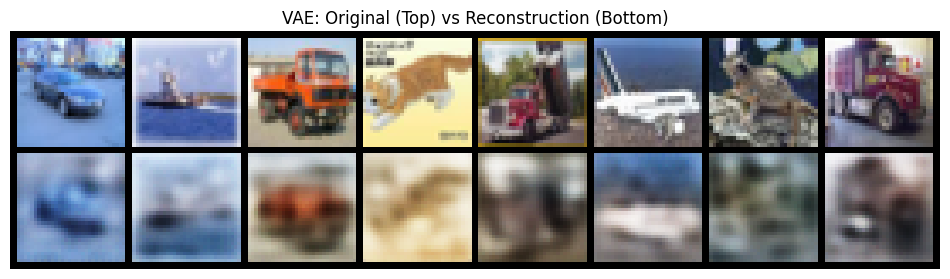

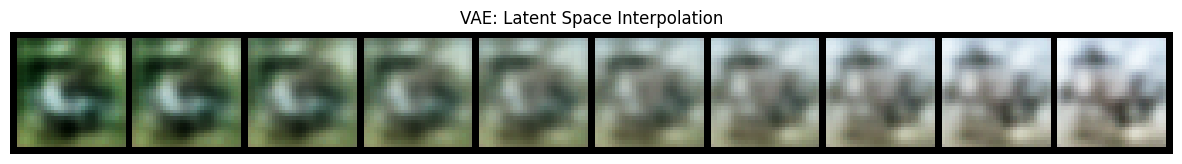

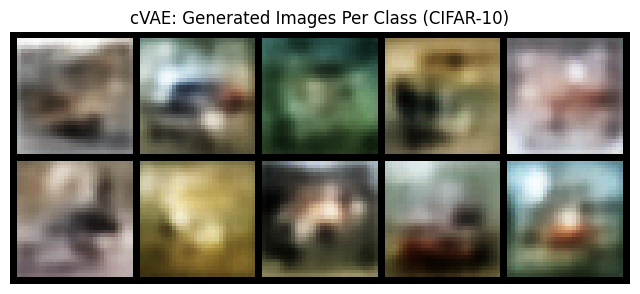

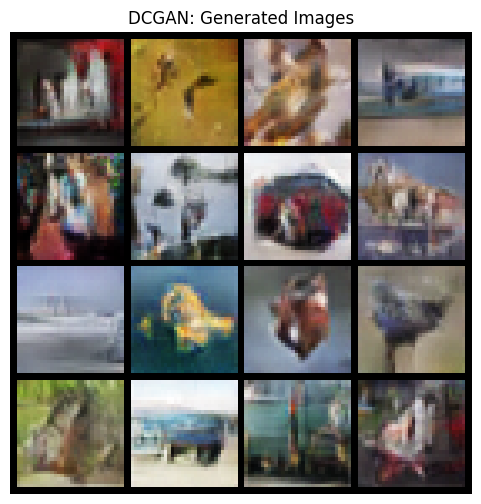

In [ ]:
vae.eval() # set VAE model to evaluation mode
cvae.eval() # set cVAE model to evaluation mode
netG.eval() # set generator model to evaluation mode

# 1. VAE: Original vs Reconstruction
sample_batch = next(iter(dataloader))[0][:8].to(device) # get a batch of real images and select the first 8
with torch.no_grad(): # disable gradient calculation for inference
  recon, _, _ = vae(sample_batch) # reconstruct selected images using VAE
grid_recon = vutils.make_grid(torch.cat([sample_batch.cpu(), recon.cpu()]), nrow=8, normalize=True) # create an image grid combining real and reconstructed images
plt.figure(figsize=(12,4)) # create a plot figure
plt.imshow(np.transpose(grid_recon.numpy(), (1,2,0))) # display the image grid
plt.title("VAE: Original (Top) vs Reconstruction (Bottom)")
plt.axis('off') # hide axes
plt.show() # render the plot

# 2. VAE: Latent Space Interpolation
with torch.no_grad(): # disable gradient calculation
  z1, z2 = torch.randn(1, nz).to(device), torch.randn(1, nz).to(device) # generate two random latent vectors
  alphas = np.linspace(0, 1, 10) # create 10 interpolation steps between 0 and 1
  imgs = [] # list to store interpolation images
  for a in alphas: # loop over interpolation steps
    z_interp = z1 * (1 - a) + z2 * a # perform linear interpolation between z1 and z2
    imgs.append(vae.decode(z_interp)) # decode the interpolated vector and save image
  grid_interp = vutils.make_grid(torch.cat(imgs), nrow=10, normalize=True) # create a grid of the interpolated images
plt.figure(figsize=(15,3)) # create a plot figure
plt.imshow(np.transpose(grid_interp.cpu().numpy(), (1,2,0))) # display the grid
plt.title("VAE: Latent Space Interpolation")
plt.axis('off') # hide axes
plt.show() # render the plot

# 3. cVAE: Generated Images Per Class (CIFAR-10)
with torch.no_grad(): # display gradient calculation
  z = torch.randn(num_classes, nz).to(device) # generate random latent vectors for each class
  labels = torch.arange(num_classes).to(device) # create labels representing every class (0-9)
  samples = cvae.decode(z, labels) # generate images conditioned on the specific class labels
grid_cvae = vutils.make_grid(samples, normalize=True, nrow=5) # create a grid of the generated cVAE images
plt.figure(figsize=(8,4)) # create plot figure
plt.imshow(np.transpose(grid_cvae.cpu().numpy(), (1,2,0))) # display grid
plt.title("cVAE: Generated Images Per Class (CIFAR-10)")
plt.axis('off') # hide axes
plt.show() # render the plot

# 4. DCGAN: Generated Images
with torch.no_grad(): # disable gradient calculation
  noise = torch.randn(16, nz, 1, 1, device=device) # generate random noise vectors for 16 images
  fake_imgs = netG(noise) # generate fake images using the DCGAN generator
grid_gan = vutils.make_grid(fake_imgs, normalize=True, nrow=4) # create a 4x4 grid of the GAN-generated images
plt.figure(figsize=(6,6)) # create a plot figure
plt.imshow(np.transpose(grid_gan.cpu().numpy(), (1,2,0))) # display the grid
plt.title("DCGAN: Generated Images")
plt.axis('off') # hide axes
plt.show() # render the plot